# Source Iteration 1D

**Purpose.** Reproduce the named radiative-transfer experiment with its original computational workflow.

**Distinction.** This notebook is the canonical study; existing code, parameters, outputs, and execution order are unchanged.


In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import os
import sys
import time
import types
from jax import vmap
import jax

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
local_mpl_toolkits = os.path.expanduser("~/.local/lib/python3.10/site-packages/mpl_toolkits")
mpl_toolkits_module = types.ModuleType("mpl_toolkits")
mpl_toolkits_module.__path__ = [local_mpl_toolkits]
sys.modules["mpl_toolkits"] = mpl_toolkits_module

import matplotlib.pyplot as plt

jax.config.update("jax_platform_name", "cpu")


sys.path.append("..")


# from utils.quadrature import leggauss

In [2]:
from configuration.rte_1d_settings import get_config

start_time = time.time()
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
kn = rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]


# def fn_source(x, v):
#     return np.zeros_like(v)


def fn_source(x, v):
    return -v / kn


fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
num_x, num_v = rte_config.model.grid_sizes  # num_v % 2 == 0
print(f"num_x = {num_x}, num_v = {num_v}")
(xmin, xmax), (vmin, vmax) = domain["x"], domain["v"]
dx = (xmax - xmin) / num_x
kn_dx = kn / dx
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
# x, xc
# quadratures = leggauss(num_v)
# mesh_v, weights = quadratures
# mesh_v = mesh_v.squeeze()
# weights = weights.squeeze()
mesh_v = np.linspace(vmin, vmax, num_v)
dv = (vmax - vmin) / (num_v - 1)
weights = np.full(num_v, dv)
weights[[0, -1]] *= 0.5
# weights = np.ones((num_v,)) * (vmax - vmin) / (num_v - 1)
v_pos = mesh_v[mesh_v > 0]
v_neg = mesh_v[mesh_v < 0]
vector_sigma_s = np.asarray(vmap(fn_sigma_s)(mesh_xc))[:, None]  # (num_x, 1)
vector_sigma_t = np.asarray(
    vmap(fn_sigma_s)(mesh_xc)[:, None] + kn**2 *
    vmap(fn_sigma_a)(mesh_xc)[:, None]
)
# vector_source = np.asarray(vmap(fn_source)(mesh_xc))[:, None]
X, V = np.meshgrid(mesh_xc, mesh_v, indexing="ij")  # shape = (num_x, num_v)
vector_source = fn_source(X, V)  # shape = (num_x, num_v)

matrix_f = np.ones((num_x + 1, num_v))
matrix_fc = np.zeros((num_x, num_v))
matrix_f[0, mesh_v > 0] = np.asarray(vmap(fn_l)(v_pos))
matrix_f[-1, mesh_v < 0] = np.asarray(vmap(fn_r)(v_neg))

num_x = 1024, num_v = 2048


In [3]:
def compute_q(matrix_f, weights, vector_sigma_s, vector_source, kn):
    matrix_fc = 0.5 * (matrix_f[1:] + matrix_f[:-1])  # shape (num_x, num_v)
    avg = 0.5 * matrix_fc @ weights[:, None]  # shape (num_x, 1)
    q = vector_sigma_s * avg + kn**2 * vector_source  # shape (num_x, num_v)
    return q

In [4]:
def source_iteration(matrix_f):
    F = matrix_f.copy()
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(-1, -num_x - 1, -1):
        F[i - 1, mesh_v < 0] = (
            q[i, mesh_v < 0] / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            - (0.5 * vector_sigma_t[i, 0] + kn_dx * v_neg)
            / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            * F[i, mesh_v < 0]
        )
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(num_x):
        F[i + 1, mesh_v > 0] = (
            q[i, mesh_v > 0] / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            - (0.5 * vector_sigma_t[i, 0] - kn_dx * v_pos)
            / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            * F[i, mesh_v > 0]
        )
    return F

In [5]:
def dvm_solver(
    matrix_f: np.array, tol: float = 1e-10, max_iter: int = 2**14
) -> np.array:
    for i in range(max_iter):
        matrix_f_new = source_iteration(matrix_f)
        diff = np.linalg.norm(matrix_f_new - matrix_f)
        print(f"Iter {i + 1}: difference = {diff:.4e}")
        if diff < tol:
            print(f"converged at iter {i + 1}")
            break
        matrix_f = matrix_f_new
    return matrix_f

In [6]:
matrix_f = dvm_solver(matrix_f)
end_time = time.time()
print(f"time taken: {end_time - start_time} seconds")

Iter 1: difference = 4.9871e+02
Iter 2: difference = 2.4491e+02
Iter 3: difference = 1.3065e+02
Iter 4: difference = 6.8139e+01
Iter 5: difference = 3.5211e+01
Iter 6: difference = 1.8193e+01
Iter 7: difference = 9.4248e+00
Iter 8: difference = 4.8941e+00
Iter 9: difference = 2.5447e+00
Iter 10: difference = 1.3239e+00
Iter 11: difference = 6.8883e-01
Iter 12: difference = 3.5842e-01
Iter 13: difference = 1.8649e-01
Iter 14: difference = 9.7034e-02
Iter 15: difference = 5.0487e-02
Iter 16: difference = 2.6269e-02
Iter 17: difference = 1.3668e-02
Iter 18: difference = 7.1115e-03
Iter 19: difference = 3.7001e-03
Iter 20: difference = 1.9252e-03
Iter 21: difference = 1.0017e-03
Iter 22: difference = 5.2119e-04
Iter 23: difference = 2.7118e-04
Iter 24: difference = 1.4109e-04
Iter 25: difference = 7.3412e-05
Iter 26: difference = 3.8197e-05
Iter 27: difference = 1.9874e-05
Iter 28: difference = 1.0341e-05
Iter 29: difference = 5.3802e-06
Iter 30: difference = 2.7994e-06
Iter 31: difference

In [7]:
X, V = np.meshgrid(mesh_x[1:-1], mesh_v[1:-1])
F = matrix_f[1:-1, 1:-1]

rho = 0.5 * (F @ weights[1:-1][:, None]).squeeze()
F = F.T
F.shape, kn

((2046, 1023), 1.0)

In [8]:
# F_ex = 1 - X
# relative_error = np.linalg.norm(F - F_ex) / np.linalg.norm(F_ex)
# print(f"relative error = {relative_error:.4e}")

In [9]:
# def plot_boundary_solutions_separate_modified():
#     """分别绘制左右边界的解 - 清晰的一行两列布局"""
#     fig, (ax1, ax2) = plt.subplots(
#         1, 2, figsize=(16, 6), dpi=500, sharey=True, constrained_layout=True
#     )

#     # 提取左边界数据 (v > 0)
#     Vl = mesh_v[1:-1][mesh_v[1:-1] > 0]
#     Fl = F[mesh_v[1:-1] > 0, 0]
#     fl = np.ones_like(Fl)   # 精确解

#     # 提取右边界数据 (v < 0)
#     Vr = mesh_v[1:-1][mesh_v[1:-1] < 0]
#     Fr = F[mesh_v[1:-1] < 0, -1]
#     fr = np.zeros_like(Fr)  # 精确解

#     # 左边界图
#     ax1.plot(Vl, fl, "-", color="#94A3C0", linewidth=3, label="Exact")
#     ax1.plot(Vl, Fl, "k--", alpha=0.5, linewidth=3, label="Numerical")
#     ax1.set_xlim([-0.1, 1.1])
#     ax1.set_ylim([-0.1, 1.1])
#     ax1.set_xlabel(r"$v$", fontsize=14)
#     ax1.set_ylabel(r"$f(0, v)$", fontsize=14)
#     ax1.set_title("Left Boundary (x=0)", fontsize=14, pad=10)
#     ax1.legend(frameon=True, loc="best")

#     # 右边界图
#     ax2.plot(Vr, fr, "-", color="#94A3C0", linewidth=3, label="Exact")
#     ax2.plot(Vr, Fr, "k--", alpha=0.5, linewidth=3, label="Numerical")
#     ax2.set_xlim([-1.1, 0.1])
#     ax2.set_ylim([-0.1, 1.1])
#     ax2.set_xlabel(r"$v$", fontsize=14)
#     ax2.set_title("Right Boundary (x=1)", fontsize=14, pad=10)
#     ax2.legend(frameon=True, loc="best")

#     # plt.suptitle(f"Distribution Function at Boundaries (kn={kn})",
#     #              fontsize=16, y=1.02)
#     plt.show()
#     plt.close()


# def print_boundary_error_modified():
#     """计算并打印边界误差"""
#     # 左边界误差
#     Fl = F[mesh_v[1:-1] > 0, 0]
#     fl = np.ones_like(Fl)
#     error_left = np.linalg.norm(Fl - fl)

#     # 右边界误差
#     Fr = F[mesh_v[1:-1] < 0, -1]
#     fr = np.zeros_like(Fr)
#     error_right = np.linalg.norm(Fr - fr)

#     print(f"Left boundary L2 error: {error_left:.6e}")
#     print(f"Right boundary L2 error: {error_right:.6e}")
#     print(f"Total boundary L2 error: {error_left + error_right:.6e}")


# # 使用示例
# print("绘制分开的边界图:")
# plot_boundary_solutions_separate_modified()
# # print_boundary_error_modified()

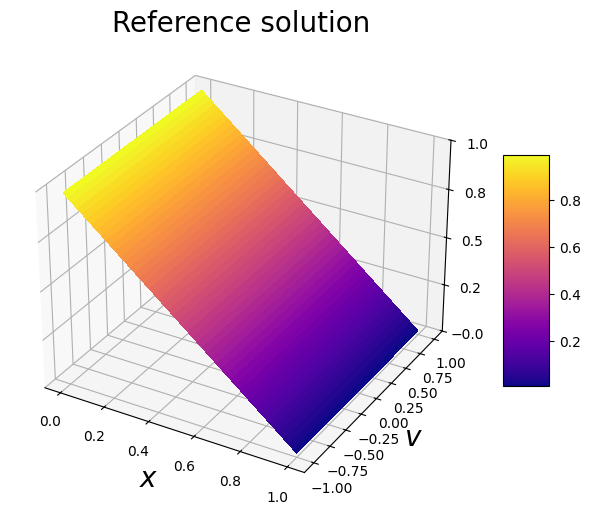

In [10]:
font_format = {"size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="plasma",
                         linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

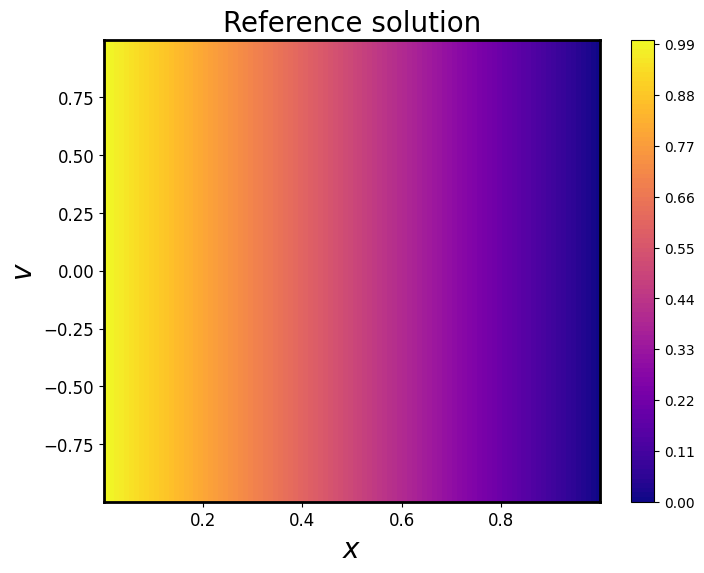

In [11]:
font_format = {"size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

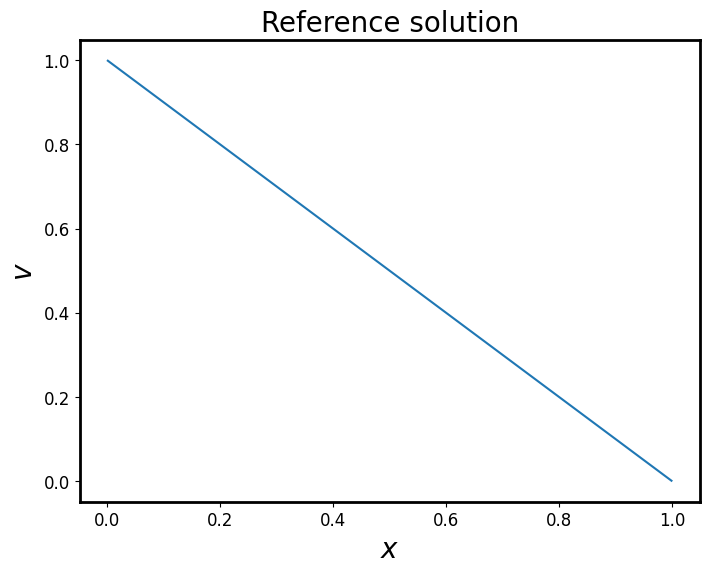

In [12]:
font_format = {"size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.plot(mesh_x[1:-1], rho)
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [13]:
# np.savez(
#     f"../data/rte1d_ex2_ref_{kn:.1e}.npz",
#     mesh_x=mesh_x[1:-1],
#     mesh_v=mesh_v[1:-1],
#     F=F,
#     rho=rho,
# )

In [14]:
# F_exact = 1.0 - X
# E = F - F_exact

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # --- 数值解 ---
# cs0 = axes[0].contourf(X, V, F, 100, cmap="plasma")
# axes[0].set_title("Numerical solution", font_format)
# axes[0].set_xlabel(r"$x$", font_format)
# axes[0].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs0, ax=axes[0])

# # --- 精确解 ---
# cs1 = axes[1].contourf(X, V, F_exact, 100, cmap="plasma")
# axes[1].set_title("Exact solution", font_format)
# axes[1].set_xlabel(r"$x$", font_format)
# axes[1].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs1, ax=axes[1])

# # --- 误差 ---
# cs2 = axes[2].contourf(X, V, E, 100, cmap="coolwarm")
# axes[2].set_title("Error", font_format)
# axes[2].set_xlabel(r"$x$", font_format)
# axes[2].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs2, ax=axes[2])

# plt.tight_layout()
# plt.show()